# Data Exploration

## Objective
Explore indoor and outdoor temperature measurements to understand basic thermal behavior of the home.

## Dataset
- Multiple temperature sensors i.e. 2 indoor (living zones) & 2 outdoor (north vs south exposure)
- Time-series data from Home Assistant export

## Data Acquisition

The data is collected using a custom smart home setup based on:

- Raspberry Pi 4 running Home Assistant
- Wireless (ZigBee) temperature and humidity sensors deployed across indoor and outdoor locations

Sensor measurements are recorded continuously and stored as time-series data, which can be exported for further analysis.

This setup allows for real-world monitoring of building thermal behavior under normal living conditions.

## Key Questions
- Do indoor and outdoor temperatures show expected patterns?
- Are there observable differences between zones (north vs south)?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load sample data
DATA_PATH = "../data/sample/PreliminaryAnalysis.csv"
df_raw = pd.read_csv(DATA_PATH)

In [3]:
# Get date after all sensors are fully operational
min_date = pd.to_datetime('2026-02-22 17:00:00')
df_raw['time'] = pd.to_datetime(df_raw['time'])
df_filtered = df_raw.loc[df_raw['time'] > min_date]

In [4]:
# Get column names from dataframe
df_filtered.columns

Index(['time', 'temp_salon_c', 'temp_kids_c', 'hum_salon', 'hum_kids',
       'temp_out_1_b_c', 'hum_out_1_b', 'temp_out_2_n_c', 'hum_out_2_n'],
      dtype='object')

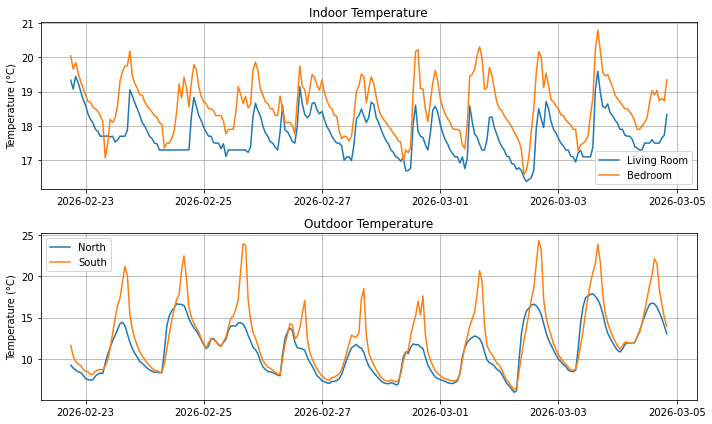

In [5]:
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(10, 6), tight_layout=True)

ax[0].plot(df_filtered['time'], df_filtered['temp_salon_c'], label="Living Room")
ax[0].plot(df_filtered['time'], df_filtered['temp_kids_c'], label="Bedroom")
ax[0].set_title("Indoor Temperature")
ax[0].set_ylabel("Temperature (°C)")
ax[0].grid()
ax[0].legend()

ax[1].plot(df_filtered['time'], df_filtered['temp_out_1_b_c'], label="North")
ax[1].plot(df_filtered['time'], df_filtered['temp_out_2_n_c'], label="South")
ax[1].set_title("Outdoor Temperature")
ax[1].set_ylabel("Temperature (°C)")
ax[1].grid()
ax[1].legend()

fig.savefig("../reports/figures/01_data_exploration/indoor_outdoor_temperatures.png", dpi=300, facecolor='white')
plt.show()

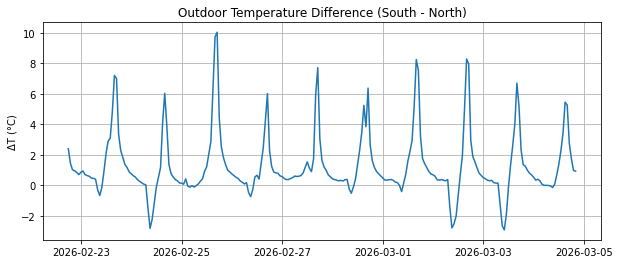

In [6]:
df_filtered = df_filtered.copy()
df_filtered['delta_outdoor'] = df_filtered['temp_out_2_n_c'] - df_filtered['temp_out_1_b_c']

plt.figure(figsize=(10,4))
plt.plot(df_filtered['time'], df_filtered['delta_outdoor'])
plt.title("Outdoor Temperature Difference (South - North)")
plt.ylabel("ΔT (°C)")
plt.grid()
plt.savefig("../reports/figures/01_data_exploration/outdoor_delta.png", dpi=300, facecolor='white')

## Initial Observations

- Outdoor temperatures exhibit a clear daily pattern with noticeable differences between north and south orientations.
- South-facing measurements consistently show higher temperatures, likely due to solar exposure.
- Indoor temperatures follow a similar pattern, in a more narrow range of values, indicating thermal inertia.
- The two indoor zones exhibit similar trends, with small offsets that may be related to orientation or usage patterns.

These observations are consistent with expected building thermal behavior and support further analysis.

## Why This Matters

Understanding the basic thermal behavior of the building is essential before moving to:

- heat loss estimation
- thermal parameter identification
- dynamic modeling and simulation

This step ensures that the dataset is consistent and physically meaningful.